# Results Analysis & Visualization

This notebook visualizes the different models from Notebook 3 and finds the best model

## Steps
1. Load trained models and predictions
2. Find the best model
3. Visualize model comparrisons
4. Feature importances
5. Dataset visualization
6. Save data

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_palette("husl")

# Define data directory
DATA_DIR = Path('../data')

print("Results Visualization Notebook")
print("=" * 50)

Results Visualization Notebook


## Load Results

In [63]:
# Load model results
df_cv_results = pd.read_csv(DATA_DIR / 'stability_classification_results.csv')

print("=== MODEL CROSS-VALIDATION RESULTS ===\n")
print(df_cv_results.to_string(index=False))

=== MODEL CROSS-VALIDATION RESULTS ===

                  Model  Test_Accuracy  Test_F1  Test_AUC  Test_Precision  Test_Recall
    Logistic Regression       0.798790 0.232731  0.702742        0.200233     0.456667
Random Forest (Shallow)       0.875076 0.238730  0.777504        0.235238     0.340000
 Random Forest (Medium)       0.909679 0.080000  0.755699        0.066667     0.100000
      Gradient Boosting       0.892317 0.088889  0.767667        0.080000     0.100000


## Best Model by AUC

## Model Comparrison Visualization

/var/folders/w3/4y_6p1q92gjg9dwqq9vfgqww0000gn/T/ipykernel_36729/1684007691.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


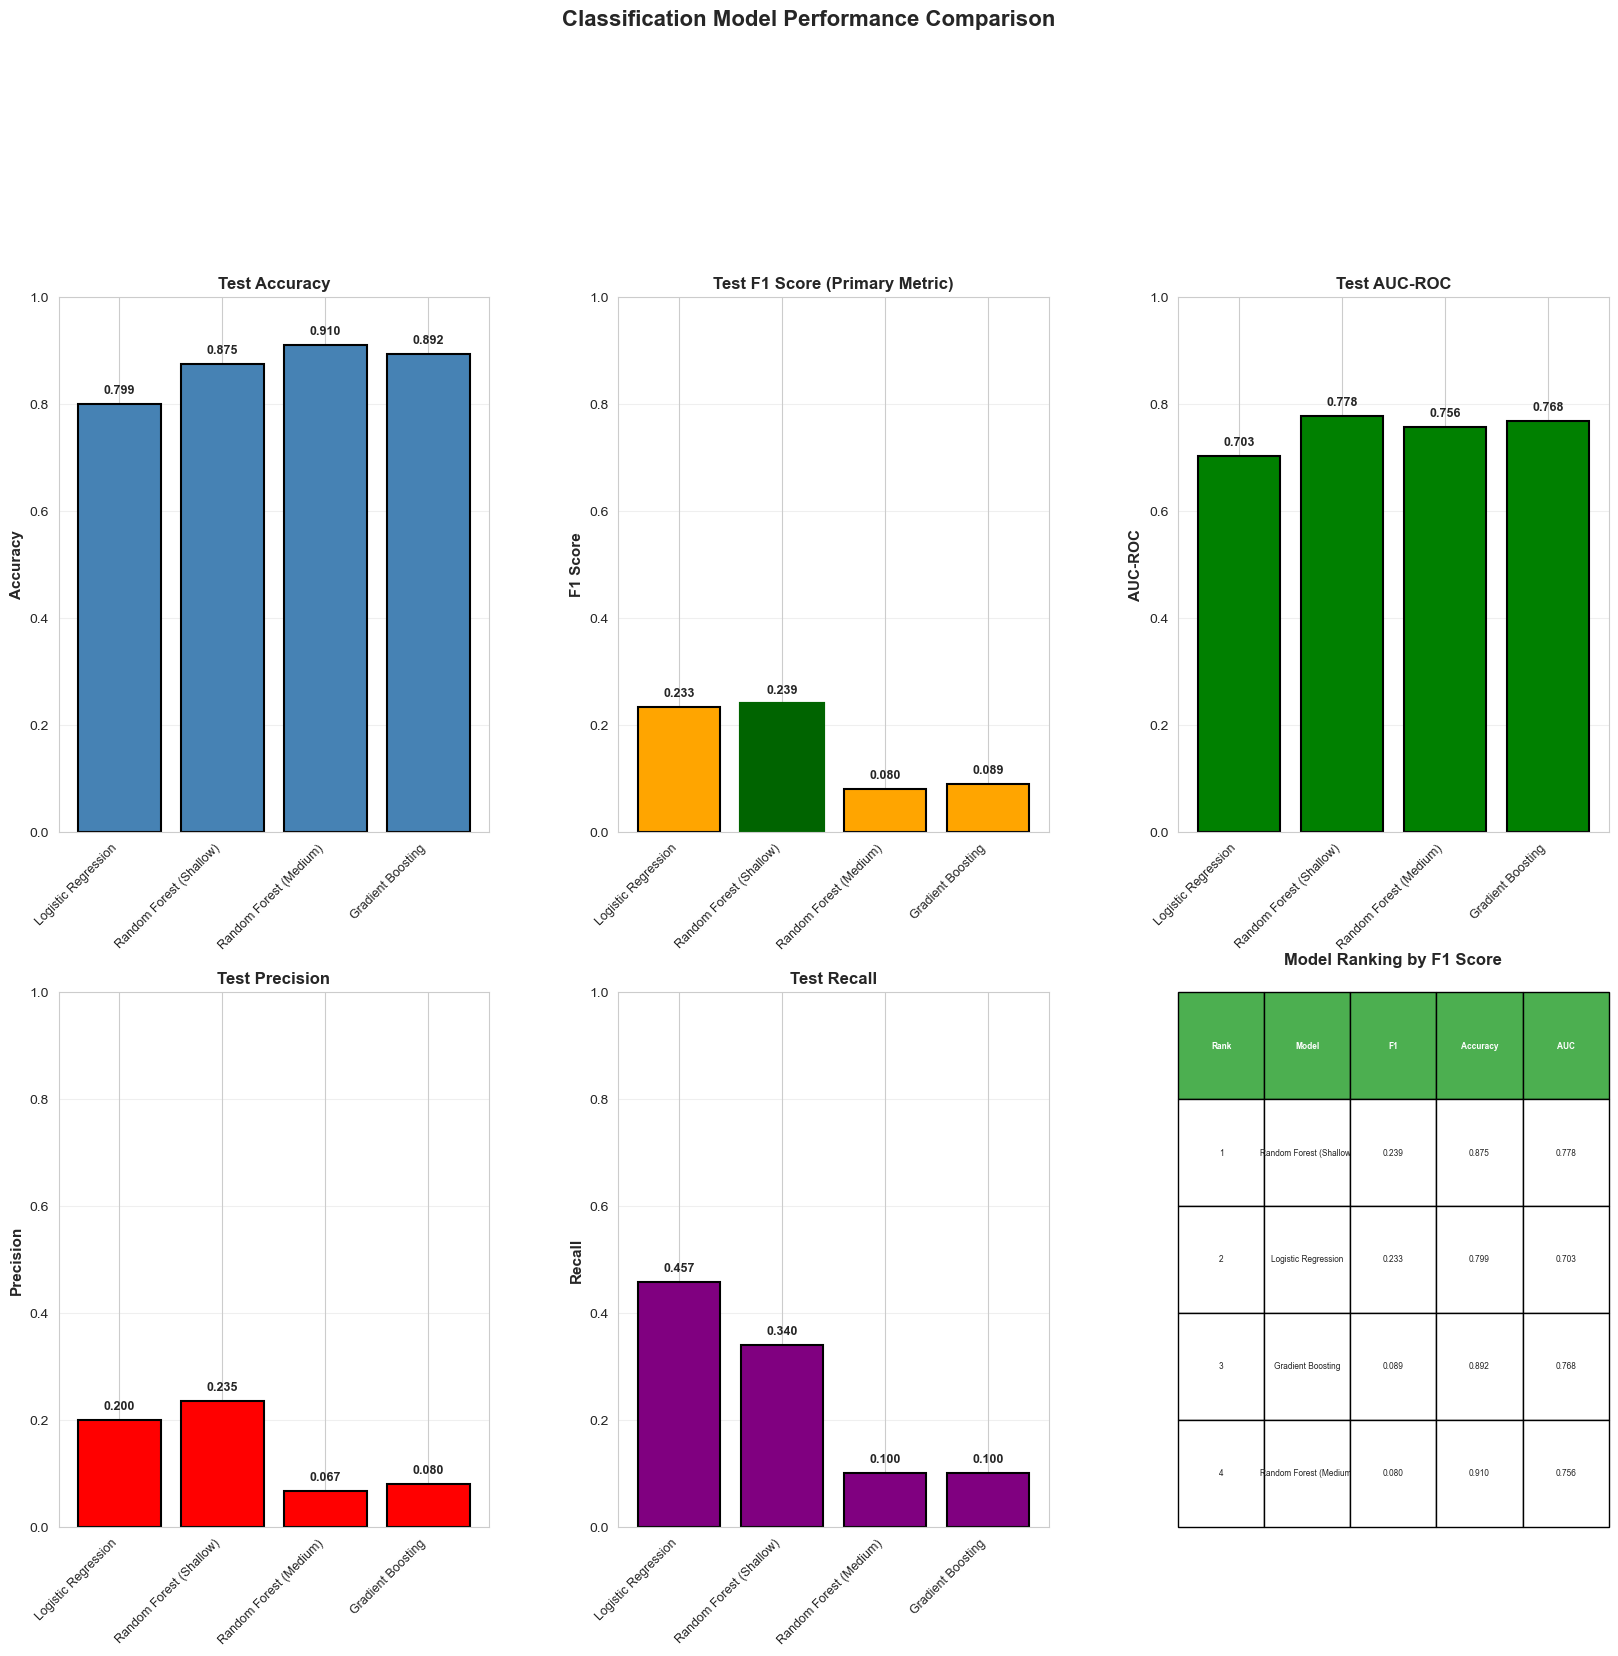

In [64]:
fig = plt.figure(figsize=(20, 25))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

metrics = ['Test_Accuracy', 'Test_F1', 'Test_AUC', 'Test_Precision', 'Test_Recall']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. Accuracy
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(len(df_cv_results)), df_cv_results['Test_Accuracy'], 
               color='steelblue', edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Test Accuracy', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(df_cv_results)))
ax1.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_Accuracy']):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 2. F1 Score
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(range(len(df_cv_results)), df_cv_results['Test_F1'], 
               color='orange', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax2.set_title('Test F1 Score (Primary Metric)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(df_cv_results)))
ax2.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
# Highlight best
best_idx = df_cv_results['Test_F1'].idxmax()
bars[best_idx].set_color('darkgreen')
bars[best_idx].set_linewidth(3)
for i, v in enumerate(df_cv_results['Test_F1']):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 3. AUC-ROC
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(range(len(df_cv_results)), df_cv_results['Test_AUC'], 
               color='green', edgecolor='black', linewidth=1.5)
ax3.set_ylabel('AUC-ROC', fontsize=11, fontweight='bold')
ax3.set_title('Test AUC-ROC', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(df_cv_results)))
ax3.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_AUC']):
    ax3.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 4. Precision
ax4 = fig.add_subplot(gs[1, 0])
bars = ax4.bar(range(len(df_cv_results)), df_cv_results['Test_Precision'], 
               color='red', edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Test Precision', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(df_cv_results)))
ax4.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_Precision']):
    ax4.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 5. Recall
ax5 = fig.add_subplot(gs[1, 1])
bars = ax5.bar(range(len(df_cv_results)), df_cv_results['Test_Recall'], 
               color='purple', edgecolor='black', linewidth=1.5)
ax5.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax5.set_title('Test Recall', fontsize=12, fontweight='bold')
ax5.set_xticks(range(len(df_cv_results)))
ax5.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax5.set_ylim([0, 1])
ax5.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_Recall']):
    ax5.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 6. Model Ranking Table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ranking_data = df_cv_results[['Model', 'Test_F1', 'Test_Accuracy', 'Test_AUC']].copy()
ranking_data = ranking_data.sort_values('Test_F1', ascending=False).reset_index(drop=True)
ranking_data['Rank'] = range(1, len(ranking_data) + 1)
ranking_data = ranking_data[['Rank', 'Model', 'Test_F1', 'Test_Accuracy', 'Test_AUC']]
ranking_data.columns = ['Rank', 'Model', 'F1', 'Accuracy', 'AUC']
ranking_data['F1'] = ranking_data['F1'].apply(lambda x: f'{x:.3f}')
ranking_data['Accuracy'] = ranking_data['Accuracy'].apply(lambda x: f'{x:.3f}')
ranking_data['AUC'] = ranking_data['AUC'].apply(lambda x: f'{x:.3f}')

table = ax6.table(cellText=ranking_data.values, colLabels=ranking_data.columns,
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1, 2)
for i in range(len(ranking_data.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax6.set_title('Model Ranking by F1 Score', fontsize=12, fontweight='bold', pad=20)


plt.suptitle('Classification Model Performance Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("../figures/model_performance_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

In [65]:
# Find best model
best_idx = df_cv_results['Test_AUC'].idxmax()
best_model = df_cv_results.loc[best_idx]

print("\n" + "=" * 70)
print("EXECUTIVE SUMMARY: TM-O Binary Oxide Stability Prediction")
print("=" * 70)

print(f"""
PROJECT OBJECTIVE:
  Find a model to predict whether TM-O binary oxide compounds are thermodynamically
  stable using 132 Magpie compositional features and 5-fold cross-validation.

BEST MODEL: {best_model['Model']}
  - Test Accuracy: {best_model['Test_Accuracy']:.4f}
  - Test F1 Score: {best_model['Test_F1']:.4f}
  - Test AUC-ROC: {best_model['Test_AUC']:.4f}
  - Test Precision: {best_model['Test_Precision']:.4f}
  - Test Recall: {best_model['Test_Recall']:.4f}

INTERPRETATION:
  The model can predict oxide stability with {best_model['Test_Accuracy']*100:.1f}% accuracy.
  An AUC score of {best_model['Test_AUC']:.4f} indicates balanced performance on both
  stable and unstable compounds.
""")


EXECUTIVE SUMMARY: TM-O Binary Oxide Stability Prediction

PROJECT OBJECTIVE:
  Find a model to predict whether TM-O binary oxide compounds are thermodynamically
  stable using 132 Magpie compositional features and 5-fold cross-validation.

BEST MODEL: Random Forest (Shallow)
  - Test Accuracy: 0.8751
  - Test F1 Score: 0.2387
  - Test AUC-ROC: 0.7775
  - Test Precision: 0.2352
  - Test Recall: 0.3400

INTERPRETATION:
  The model can predict oxide stability with 87.5% accuracy.
  An AUC score of 0.7775 indicates balanced performance on both
  stable and unstable compounds.



## Feature Importances

In [66]:
try:
    df_feature_importance = pd.read_csv(DATA_DIR / 'feature_importance_stability.csv')
    
    print("=== TOP 15 MOST IMPORTANT FEATURES ===\n")
    print(df_feature_importance.head(15).to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(figsize=(16, 10))
    
    # Top 15 features
    top_15 = df_feature_importance.head(15)
    axes.barh(range(len(top_15)), top_15['importance'], color='steelblue', edgecolor='black')
    axes.set_yticks(range(len(top_15)))
    axes.set_yticklabels(top_15['feature'], fontsize=9)
    axes.set_xlabel('Feature Importance', fontsize=11, fontweight='bold')
    axes.set_title('Top 15 Most Important Features for Stability Prediction', fontsize=12, fontweight='bold')
    axes.invert_yaxis()
    axes.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig("../figures/feature_importances.png", dpi=100, bbox_inches="tight")
    plt.show()
    
except FileNotFoundError:
    print("Feature importance file not found. Run modeling notebook first.")

Feature importance file not found. Run modeling notebook first.


## Original Dataset Visualization

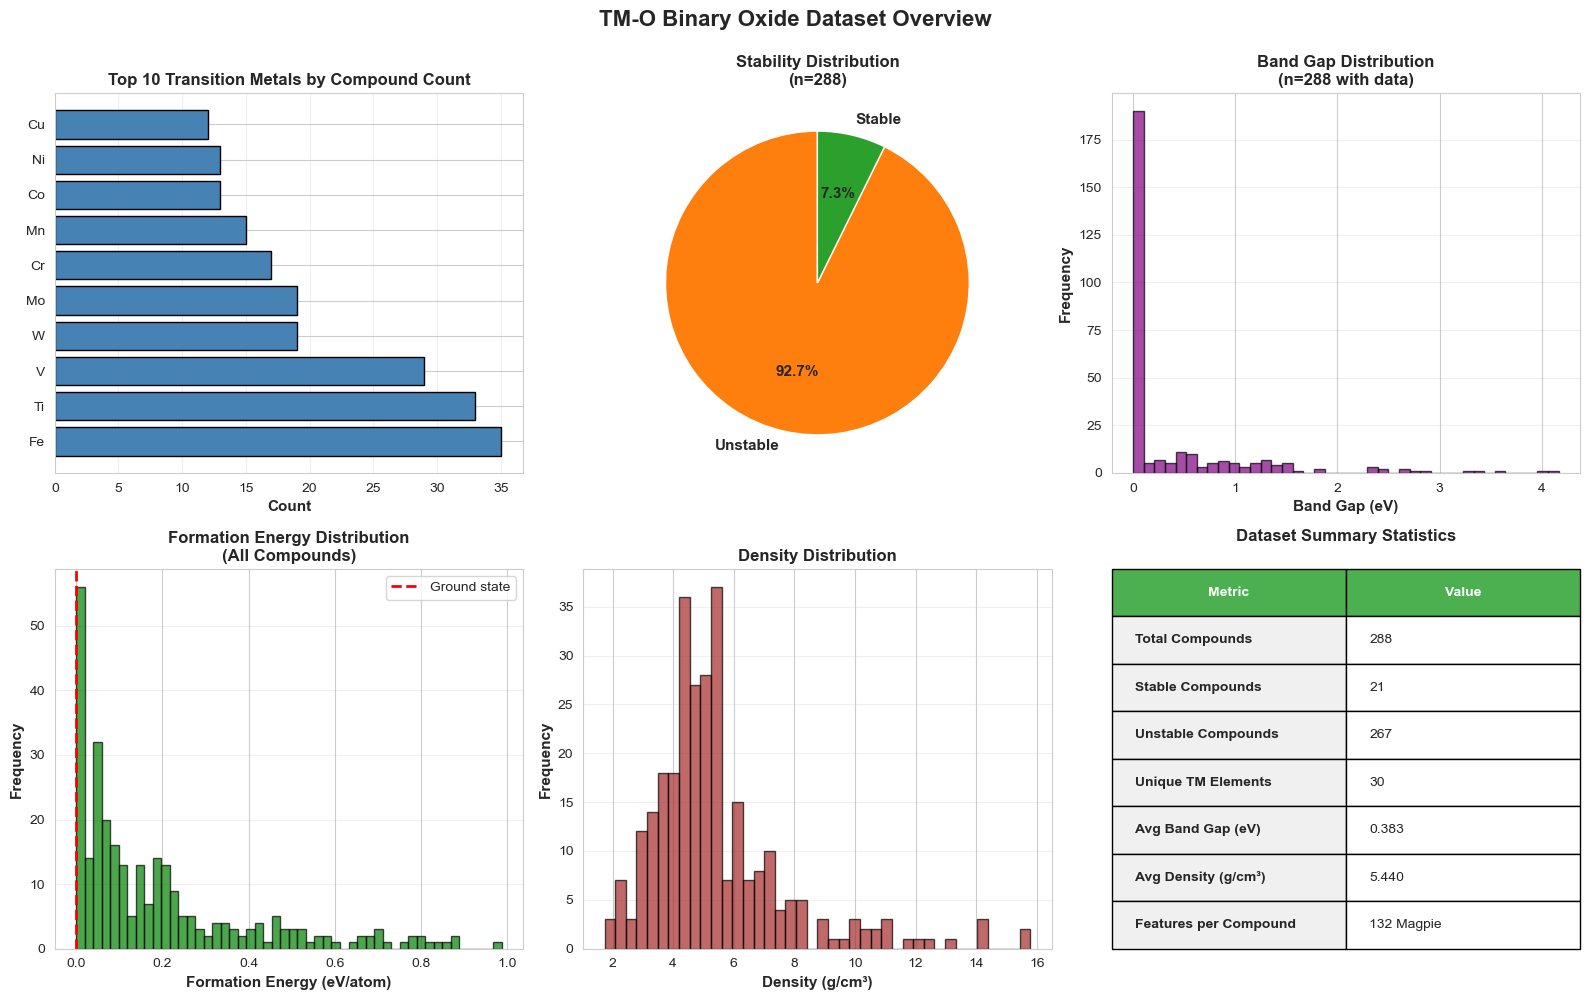

In [67]:
df_original = pd.read_csv(DATA_DIR / 'tm_oxygen_binary_compounds.csv')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Total compounds by transition metal
ax = axes[0, 0]
tm_counts = df_original['transition_metal'].value_counts().sort_values(ascending=False).head(10)
ax.barh(range(len(tm_counts)), tm_counts.values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(tm_counts)))
ax.set_yticklabels(tm_counts.index, fontsize=10)
ax.set_xlabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Transition Metals by Compound Count', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 2. Stability distribution
ax = axes[0, 1]
stability_counts = df_original['is_stable'].value_counts()
colors_pie = ['#ff7f0e', '#2ca02c']
wedges, texts, autotexts = ax.pie([stability_counts[False], stability_counts[True]], 
                                    labels=['Unstable', 'Stable'],
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title(f'Stability Distribution\n(n={len(df_original)})', fontsize=12, fontweight='bold')

# 3. Band gap distribution
ax = axes[0, 2]
band_gap_valid = df_original[df_original['band_gap'] != -1]['band_gap']
ax.hist(band_gap_valid, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Band Gap (eV)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title(f'Band Gap Distribution\n(n={len(band_gap_valid)} with data)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. Formation energy distribution
ax = axes[1, 0]
ax.hist(df_original['energy_above_hull'], bins=50, color='green', edgecolor='black', alpha=0.7)
ax.set_xlabel('Formation Energy (eV/atom)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Formation Energy Distribution\n(All Compounds)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ground state')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 5. Density distribution
ax = axes[1, 1]
ax.hist(df_original['density'], bins=40, color='brown', edgecolor='black', alpha=0.7)
ax.set_xlabel('Density (g/cm³)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Density Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 6. Summary statistics table
ax = axes[1, 2]
ax.axis('off')
summary_stats = [
    ['Total Compounds', f"{len(df_original)}"],
    ['Stable Compounds', f"{df_original['is_stable'].sum()}"],
    ['Unstable Compounds', f"{(~df_original['is_stable']).sum()}"],
    ['Unique TM Elements', f"{df_original['transition_metal'].nunique()}"],
    ['Avg Band Gap (eV)', f"{band_gap_valid.mean():.3f}"],
    ['Avg Density (g/cm³)', f"{df_original['density'].mean():.3f}"],
    ['Features per Compound', '132 Magpie'],
]

table = ax.table(cellText=summary_stats, colLabels=['Metric', 'Value'],
                cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)
for i in range(2):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(summary_stats) + 1):
    table[(i, 0)].set_facecolor('#f0f0f0')
    table[(i, 0)].set_text_props(weight='bold')

ax.set_title('Dataset Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.suptitle('TM-O Binary Oxide Dataset Overview', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("../figures/dataset_overview.png", dpi=100, bbox_inches="tight")
plt.show()

## Summary Table

In [68]:
export_results = df_cv_results.copy()
export_results = export_results[['Model', 'Test_Accuracy', 'Test_F1', 'Test_AUC', 'Test_Precision', 'Test_Recall']]
export_results.columns = ['Model', 'Accuracy', 'F1 Score', 'AUC-ROC', 'Precision', 'Recall']

# Round to 4 decimal places
for col in ['Accuracy', 'F1 Score', 'AUC-ROC', 'Precision', 'Recall']:
    export_results[col] = export_results[col].apply(lambda x: f'{x:.4f}')

export_results = export_results.sort_values('F1 Score', ascending=False)

print("\n" + "=" * 80)
print("FINAL RESULTS TABLE (for paper/presentation)")
print("=" * 80 + "\n")
print(export_results.to_string(index=False))

# Save as clean CSV
export_file = DATA_DIR / 'final_results_table.csv'
export_results.to_csv(export_file, index=False)
print(f"\nExported to {export_file}")


FINAL RESULTS TABLE (for paper/presentation)

                  Model Accuracy F1 Score AUC-ROC Precision Recall
Random Forest (Shallow)   0.8751   0.2387  0.7775    0.2352 0.3400
    Logistic Regression   0.7988   0.2327  0.7027    0.2002 0.4567
      Gradient Boosting   0.8923   0.0889  0.7677    0.0800 0.1000
 Random Forest (Medium)   0.9097   0.0800  0.7557    0.0667 0.1000

Exported to ../data/final_results_table.csv
